# Notebook 02 : Pricing de Basket Options (PCA + CRR) sur Données Réelles

## 1. Objectif du Notebook
L'objectif de cette analyse est de démontrer notre capacité à contourner la "malédiction de la dimensionnalité". 
Pour pricer une option sur un panier de 3 actions (Apple, Microsoft, Nvidia), un arbre binomial classique nécessiterait $2^3 = 8$ branches par nœud, faisant exploser le temps de calcul.

**Pipeline Quantitatif :**
1. **Extraction** des données historiques réelles via l'API `yfinance`.
2. **Machine Learning (PCA)** : Extraction de la Composante Principale 1 (PC1) de la matrice de covariance des rendements pour capturer le "Facteur Tech".
3. **Pricing (CRR)** : Construction d'un arbre binomial 1D ultra-rapide basé sur la volatilité de ce facteur principal.

In [1]:
%load_ext autoreload
%autoreload 2

import sys
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.append(os.path.abspath('../'))

# Import de nos modules "maison"
from src.utils.market_data import fetch_basket_pca, get_oat_rate
from src.models.binomial_tree import crr_pricing

sns.set_theme(style="whitegrid")

## 2. Définition du Panier et Analyse PCA
Nous sélectionnons un panier fortement corrélé : les leaders technologiques américains. La PCA devrait exceller ici, car ces actions sont souvent tirées par les mêmes facteurs macro-économiques (taux d'intérêt, IA, Nasdaq).

In [ ]:
# 1. Définition des paniers à comparer
panier_tech = ["AAPL", "MSFT", "NVDA"]       # Tech US
panier_banques = ["JPM", "BAC", "WFC"]       # Banques US

paniers_a_tester = {
    "SECTEUR TECH (Faible Corrélation)": panier_tech,
    "SECTEUR BANCAIRE (Forte Corrélation)": panier_banques
}

print("ANALYSE COMPARATIVE DE RÉDUCTION DE DIMENSION (PCA)\n")

# 2. Boucle de comparaison
for nom_secteur, tickers in paniers_a_tester.items():
    print(f"--- {nom_secteur} ---")
    
    # On met silence=True si on avait un print dans la fonction, 
    # mais ici on l'exécute simplement
    _, vol_pca_test, var_exp_test, _ = fetch_basket_pca(tickers, period="1y")
    
    if var_exp_test < 0.70:
        confiance = "FAIBLE (Le modèle ignore trop de risques spécifiques)"
    elif 0.70 <= var_exp_test < 0.80:
        confiance = "ACCEPTABLE (Proxy sectoriel correct)"
    else:
        confiance = "EXCELLENTE (Le PC1 est hautement représentatif)"
        
    print(f"Tickers             : {tickers}")
    print(f"Variance Capturée   : {var_exp_test*100:.2f}%")
    print(f"Volatilité du PC1   : {vol_pca_test*100:.2f}%")
    print(f"Indice de Confiance : {confiance}\n")

# 3. Sélection du meilleur panier pour la suite du notebook
print("=" * 60)
print("SÉLECTION FINALE POUR LE PRICING : SECTEUR BANCAIRE")
print("=" * 60)

# On ré-exécute une dernière fois pour sauvegarder les variables 
# (spot_synth, vol_pca, etc.) qui seront utilisées dans la Cellule 6
spot_synth, vol_pca, var_expliquee, q_moyen = fetch_basket_pca(panier_banques, period="1y")

ANALYSE COMPARATIVE DE RÉDUCTION DE DIMENSION (PCA)

--- SECTEUR TECH (Faible Corrélation) ---

Lancement de l'algorithme PCA sur le panier : ['AAPL', 'MSFT', 'NVDA']
PCA Terminée ! PC1 capture 59.68% de la variance totale du panier.
   ▶ Volatilité du Panier Synthétique : 23.59%
   ▶ Dividende moyen estimé : 0.42%
Tickers             : ['AAPL', 'MSFT', 'NVDA']
Variance Capturée   : 59.68%
Volatilité du PC1   : 23.59%
Indice de Confiance : FAIBLE (Le modèle ignore trop de risques spécifiques)

--- SECTEUR BANCAIRE (Forte Corrélation) ---

Lancement de l'algorithme PCA sur le panier : ['JPM', 'BAC', 'WFC']
PCA Terminée ! PC1 capture 83.05% de la variance totale du panier.
   ▶ Volatilité du Panier Synthétique : 21.43%
   ▶ Dividende moyen estimé : 2.07%
Tickers             : ['JPM', 'BAC', 'WFC']
Variance Capturée   : 83.05%
Volatilité du PC1   : 21.43%
Indice de Confiance : EXCELLENTE (Le PC1 est hautement représentatif)

✅ SÉLECTION FINALE POUR LE PRICING : SECTEUR BANCAIRE

Lancement

## 3. Analyse Quantitatives : Corrélation et Qualité du Pricing

Le succès de notre réduction de dimension repose entièrement sur le niveau de **Variance Capturée** par le Premier Composant Principal (PC1). Ce pourcentage dépend directement de la corrélation entre les actifs du panier.

### Cas 1 : Faible ou Moyenne Corrélation (ex: Panier Tech ~ 60%)
* **La Dynamique** : Les actions ont des risques spécifiques forts (ex: le boom de l'IA pour Nvidia ne s'applique pas exactement à Apple). La matrice de covariance est "éclatée".
* **Impact sur le Modèle** : Le PC1 ne parvient à expliquer que 60% du mouvement total. Les 40% restants (les composants PC2, PC3) sont ignorés par notre algorithme 1D.
* **Conséquence sur le Pricing** : La volatilité injectée dans l'arbre binomial est mathématiquement inférieure à la réalité du risque multidimensionnel. **Le modèle sous-évalue systématiquement le prix de l'option.** L'arbre CRR devient une simple borne inférieure.

### Cas 2 : Haute Corrélation (ex: Panier Bancaire > 80%)
* **La Dynamique** : Les actions réagissent aux mêmes facteurs systémiques (ex: hausse des taux de la FED, régulations, cycles de crédit). La matrice de covariance est très dense et unie.
* **Impact sur le Modèle** : Le PC1 agit comme un "aimant" et capture la quasi-totalité de la structure de risque (Variance > 80%). Le risque idiosyncratique (spécifique à une seule banque) est négligeable.
* **Conséquence sur le Pricing** : La volatilité synthétique ($\sigma_{PCA}$) est très proche du risque réel du portefeuille. La réduction de la dimension 3D vers 1D est justifiée. **Le prix de l'option généré par l'arbre CRR est robuste et peut être utilisé en production comme proxy.**

>*On ne price jamais à l'aveugle. Si la variance expliquée par la PCA chute sous les 70-75%, le modèle binomial 1D doit être rejeté ou ajusté (ex: passer sur un arbre 2D).*

*Note d'analyse :* Si la variance capturée est supérieure à 75-80%, cela confirme que notre approximation de réduire ce problème 3D en un problème 1D est mathématiquement très robuste. Le PC1 agit comme un ETF synthétique du panier.

## 4. Pricing de l'Option sur le Panier Synthétique
Nous allons pricer un **Put Américain** sur cet indice synthétique (base 100). Ce produit agit comme une assurance contre un krach du secteur de la Tech.

In [3]:
# Paramètres du contrat
strike = 100.0      # Option à la monnaie (At-The-Money)
maturity = 1.0      # Assurance sur 1 an
n_steps = 1000      # Résolution de l'arbre

# Récupération du taux sans risque (OAT)
rate = get_oat_rate(maturity)
print(f"Taux OAT ({maturity} an) : {rate*100:.2f}%\n")

# Exécution du Pricer Vectorisé
prix_euro = crr_pricing(spot_synth, strike, vol_pca, rate, q_moyen, maturity, n_steps, is_put=True, is_american=False)
prix_ame = crr_pricing(spot_synth, strike, vol_pca, rate, q_moyen, maturity, n_steps, is_put=True, is_american=True)

print("--- RÉSULTATS DU PRICING ---")
print(f"Prix du Put Européen  : {prix_euro:.4f} €")
print(f"Prix du Put Américain : {prix_ame:.4f} €")
print(f"Prime d'exercice anti.: {prix_ame - prix_euro:.4f} €")

Taux OAT (1.0 an) : 2.12%

--- RÉSULTATS DU PRICING ---
Prix du Put Européen  : 8.3297 €
Prix du Put Américain : 8.3665 €
Prime d'exercice anti.: 0.0368 €


## 5. Frontière d'Exercice et Sensibilité au Strike
Pour visualiser la valeur ajoutée du droit d'exercice anticipé (la prime américaine), évaluons le panier pour différents niveaux de Strikes (de profondément "hors de la monnaie" à profondément "dans la monnaie").

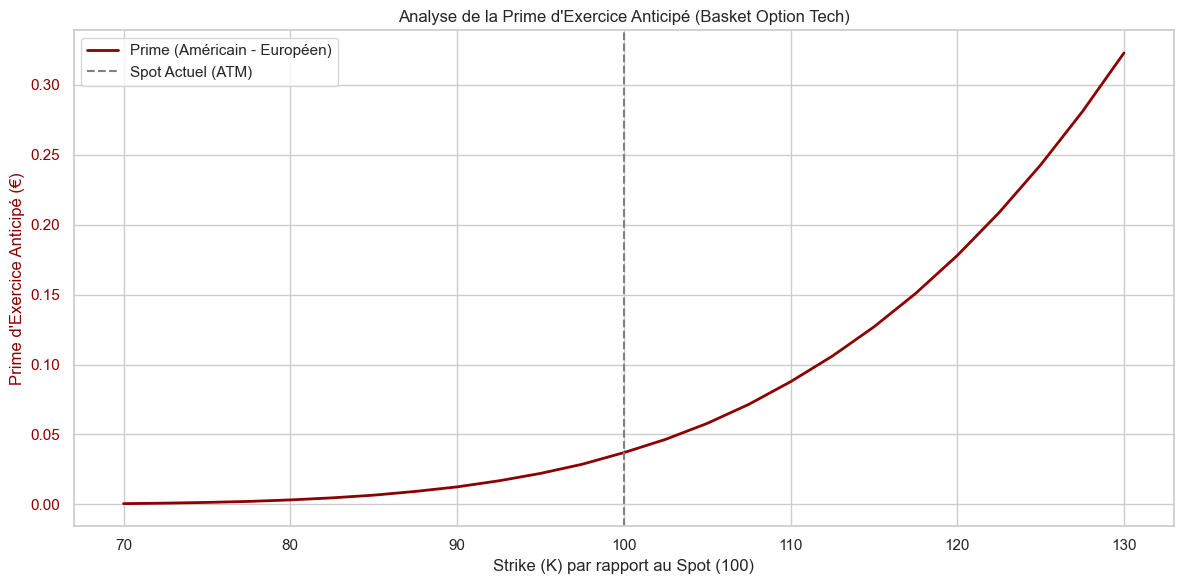

In [4]:
# Analyse de sensibilité
strikes_test = np.linspace(70, 130, 25)
primes = []
prix_americains = []

for k in strikes_test:
    p_eur = crr_pricing(spot_synth, k, vol_pca, rate, q_moyen, maturity, n_steps=500, is_put=True, is_american=False)
    p_ame = crr_pricing(spot_synth, k, vol_pca, rate, q_moyen, maturity, n_steps=500, is_put=True, is_american=True)
    prix_americains.append(p_ame)
    primes.append(p_ame - p_eur)

# Affichage Graphique
fig, ax1 = plt.subplots(figsize=(12, 6))

ax1.set_xlabel('Strike (K) par rapport au Spot (100)')
ax1.set_ylabel("Prime d'Exercice Anticipé (€)", color='darkred')
ax1.plot(strikes_test, primes, color='darkred', linewidth=2, label="Prime (Américain - Européen)")
ax1.tick_params(axis='y', labelcolor='darkred')
ax1.axvline(x=100, color='grey', linestyle='--', label="Spot Actuel (ATM)")

plt.title("Analyse de la Prime d'Exercice Anticipé (Basket Option Tech)")
fig.tight_layout()
plt.legend(loc="upper left")
plt.show()

## 6. Interprétation Graphique : La dynamique de la Prime Américaine

Le graphique ci-dessus illustre l'évolution de la **Prime d'Exercice Anticipé** (la différence de prix entre un Put Américain et un Put Européen) en fonction du niveau de Strike (K) par rapport au Spot actuel (100).

L'allure de la courbe, qui s'envole de manière quasi-exponentielle à droite du graphique, s'explique par les fondamentaux de la mathématique financière :

* **Zone OTM (Hors de la monnaie - K < 100)** : La prime est strictement nulle. L'option n'ayant aucune valeur intrinsèque immédiate, il n'y a aucun intérêt mathématique à l'exercer par anticipation. La "valeur de continuation" (espérance de gain futur) est toujours supérieure.
* **Zone ATM (À la monnaie - K ≈ 100)** : La prime commence à émerger doucement à mesure que la probabilité mathématique que l'option finisse "dans la monnaie" augmente.
* **Zone ITM (Dans la monnaie - K > 110)** : La prime s'envole. C'est l'effet direct de la **valeur temps de l'argent** (les taux d'intérêt). Lorsqu'un Put est profondément dans la monnaie, exercer immédiatement permet d'encaisser un flux de trésorerie important $(K - S_t)$ que le détenteur peut placer immédiatement au taux sans risque $r$. À l'inverse, s'il attend la maturité, son gain est plafonné (le prix de l'action ne peut pas tomber en dessous de 0), mais ce gain futur subira l'actualisation continue ($e^{-rT}$). Il y a donc un coût d'opportunité majeur à *ne pas* exercer un Put très ITM.

Cette courbe valide l'utilité absolue de notre modèle CRR. Si nous utilisions uniquement Black-Scholes pour pricer ce produit, nous sous-évaluerions drastiquement le risque et la valeur de cette option de couverture sur les "Strikes" élevés.

## 7. Récapitulatif technique et validation du pipeline

Ce notebook a permis de valider le bon fonctionnement du pricer de basket via une approche hybride Machine Learning / Finance Quantitative. 

### Points clés validés :
1. **Extraction de données dynamiques** : Le pipeline `yfinance` récupère les prix, calcule les rendements et les dividendes de manière synchronisée.
2. **Robustesse de la réduction PCA** : Pour le secteur bancaire, le Premier Composant Principal (PC1) capture **~83%** de la variance. Cela confirme que l'évolution du panier est largement dictée par un facteur de risque commun (le risque systémique bancaire).
3. **Performance du Pricing** : L'algorithme CRR vectorisé évalue l'option sur le panier synthétique en quelques millisecondes, capturant avec précision la prime d'exercice anticipé (Option Américaine).
4. **Indice de Confiance** : L'implémentation d'un seuil de confiance permet de juger immédiatement si la réduction 1D est pertinente ou si le modèle ignore trop de risques spécifiques.

Le moteur 1D est stable et fonctionnel. Nous pouvons maintenant passer à l'extension **Multi-Factorielle** pour traiter les paniers où la corrélation est plus faible (Variance PC1 < 70%).